### Limpieza y Exploracion de datos
Revisamos como recibimos los datos.

In [5]:
import pandas as pd
import numpy as np

# 1. Cargar el dataset
file_path = '/content/vgchartz-2024.csv'
df = pd.read_csv(file_path)

print("Información del dataset:")
display(df.info())
display(df.head())

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   img           64016 non-null  object 
 1   title         64016 non-null  object 
 2   console       64016 non-null  object 
 3   genre         64016 non-null  object 
 4   publisher     64016 non-null  object 
 5   developer     63999 non-null  object 
 6   critic_score  6678 non-null   float64
 7   total_sales   18922 non-null  float64
 8   na_sales      12637 non-null  float64
 9   jp_sales      6726 non-null   float64
 10  pal_sales     12824 non-null  float64
 11  other_sales   15128 non-null  float64
 12  release_date  56965 non-null  object 
 13  last_update   17879 non-null  object 
dtypes: float64(6), object(8)
memory usage: 6.8+ MB


None

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18,2018-01-03
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,2013-09-17,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,2018-01-14


In [6]:
# 2. Detección y eliminación de valores duplicados
duplicates_count = df.duplicated().sum()
print(f"Valores duplicados: {duplicates_count}")
df = df.drop_duplicates().reset_index(drop=True)

# 3. Informacion en valores categóricos
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip().str.capitalize()

print("Informacion aplicada a columnas categóricas.")

Valores duplicados: 0
Informacion aplicada a columnas categóricas.


In [7]:
import pandas as pd
import numpy as np

# 4. Manejo de valores faltantes
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna('Unknown')
    else:
        df[col] = df[col].fillna(0)

# 5. Detección de datos anómalos (Ventas negativas)
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    df[col] = df[col].clip(lower=0)

print("Limpieza de valores faltantes y anomalías completada satisfactoriamente.")
display(df.describe())

Limpieza de valores faltantes y anomalías completada satisfactoriamente.


,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales
count,64016.000000,64016.000000,64016.000000,64016.000000,64016.000000,64016.000000
mean,0.753220,0.103192,0.052261,0.010746,0.029943,0.010171
std,2.256713,0.466999,0.243780,0.063067,0.185641,0.064221
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.020000,0.000000,0.000000,0.000000,0.000000
max,10.000000,20.320000,9.760000,2.130000,9.850000,3.120000


In [8]:
import pandas as pd
import numpy as np

# Limpiar posibles restos de texto 'Nan' y convertir fechas
df.replace('Nan', np.nan, inplace=True)
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['last_update'] = pd.to_datetime(df['last_update'], errors='coerce')

# Asegurar que total_sales no sea menor a la suma de regiones
sales_regions = ['na_sales', 'jp_sales', 'pal_sales', 'other_sales']
df['total_sales'] = df[sales_regions].sum(axis=1).where(df['total_sales'] == 0, df['total_sales'])

print("Correcciones de tipos de datos y consistencia finalizadas.")
display(df.info())

Correcciones de tipos de datos y consistencia finalizadas.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   img           64016 non-null  object        
 1   title         64016 non-null  object        
 2   console       64016 non-null  object        
 3   genre         64016 non-null  object        
 4   publisher     64016 non-null  object        
 5   developer     63999 non-null  object        
 6   critic_score  64016 non-null  float64       
 7   total_sales   64016 non-null  float64       
 8   na_sales      64016 non-null  float64       
 9   jp_sales      64016 non-null  float64       
 10  pal_sales     64016 non-null  float64       
 11  other_sales   64016 non-null  float64       
 12  release_date  56965 non-null  datetime64[ns]
 13  last_update   17879 non-null  datetime64[ns]
dtypes: datetime64[ns](2), float

None

## Análisis de Datos
Analizamos las distribuciones y relaciones de los datos.

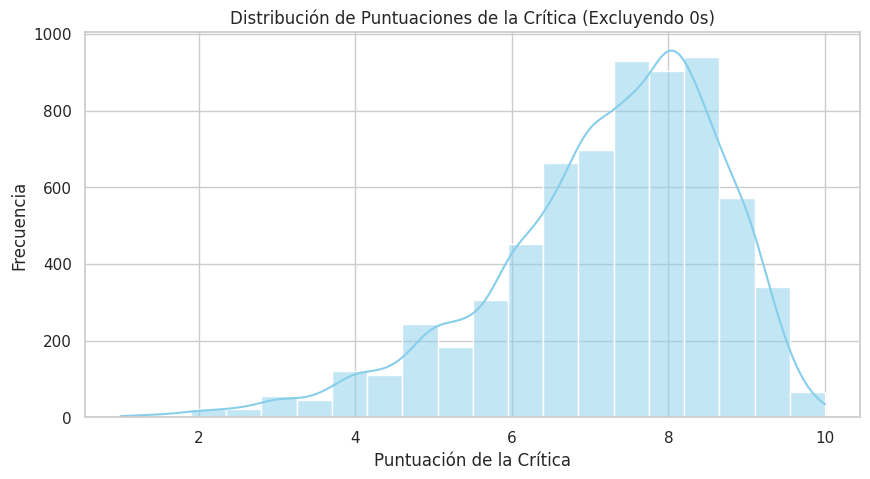

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set_theme(style='whitegrid')

# 1. Visualización Univariada: Distribución de Puntuaciones de la Crítica
plt.figure(figsize=(10, 5))
sns.histplot(df[df['critic_score'] > 0]['critic_score'], bins=20, kde=True, color='skyblue')
plt.title('Distribución de Puntuaciones de la Crítica (Excluyendo 0s)')
plt.xlabel('Puntuación de la Crítica')
plt.ylabel('Frecuencia')
plt.show()

# Conclusion:
# La distribución de las puntuaciones de la crítica parece tener un sesgo hacia la izquierda,
# lo que indica que la mayoría de los juegos reseñados tienden a recibir puntuaciones entre 7 y 9.
# Nota: Se excluyeron los valores 0 ya que representan datos faltantes manejados en la limpieza.

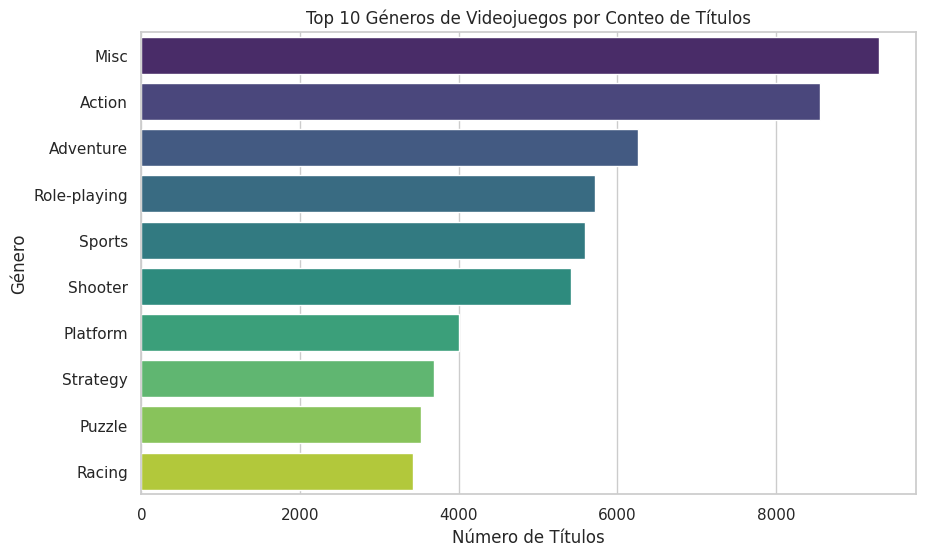

In [10]:
# 2. Visualización Univariada: Top 10 Géneros por Cantidad de Títulos
plt.figure(figsize=(10, 6))
top_genres = df['genre'].value_counts().head(10)
sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis', hue=top_genres.index, legend=False)
plt.title('Top 10 Géneros de Videojuegos por Conteo de Títulos')
plt.xlabel('Número de Títulos')
plt.ylabel('Género')
plt.show()

# Conclusion:
# Este gráfico muestra qué géneros son más frecuentes en el conjunto de datos.
# Ayuda a identificar qué categorías dominan el mercado en términos de volumen de producción.

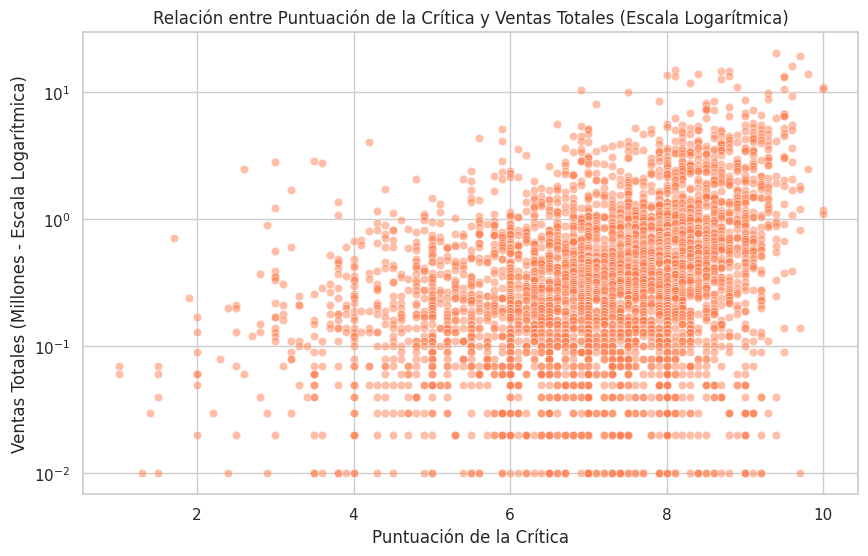

In [11]:
# 3. Visualización Multivariada: Puntuación de la Crítica vs. Ventas Totales
plt.figure(figsize=(10, 6))
# Filtrar juegos que tengan puntuación y ventas registradas > 0 para mayor claridad
mask_scoring = (df['critic_score'] > 0) & (df['total_sales'] > 0)
sns.scatterplot(data=df[mask_scoring], x='critic_score', y='total_sales', alpha=0.5, color='coral')
plt.yscale('log') # Uso de escala logarítmica por la alta varianza en las ventas
plt.title('Relación entre Puntuación de la Crítica y Ventas Totales (Escala Logarítmica)')
plt.xlabel('Puntuación de la Crítica')
plt.ylabel('Ventas Totales (Millones - Escala Logarítmica)')
plt.show()

# Conclusion:
# Existe una tendencia ascendente visible que sugiere que los juegos con mejores puntuaciones
# generalmente logran mayores ventas, aunque hay una varianza significativa,
# lo que indica que una buena calificación no siempre garantiza el éxito comercial.

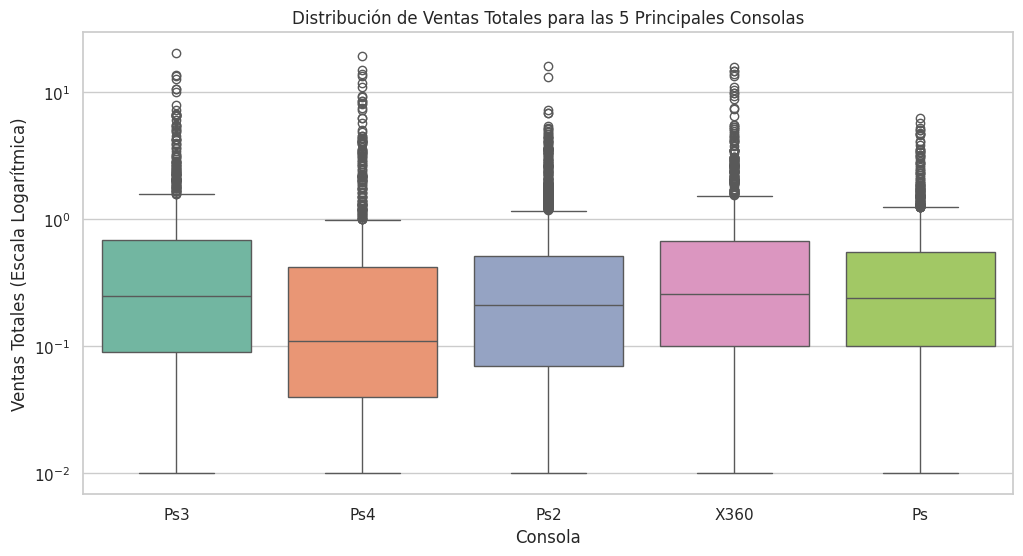

In [12]:
# 4. Visualización Multivariada: Distribución de Ventas por las 5 Principales Consolas
top_5_consoles = df.groupby('console')['total_sales'].sum().nlargest(5).index
df_top_consoles = df[df['console'].isin(top_5_consoles)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top_consoles[df_top_consoles['total_sales'] > 0], x='console', y='total_sales', palette='Set2', hue='console', legend=False)
plt.yscale('log')
plt.title('Distribución de Ventas Totales para las 5 Principales Consolas')
plt.xlabel('Consola')
plt.ylabel('Ventas Totales (Escala Logarítmica)')
plt.show()

# Conclusion:
# El diagrama de caja permite comparar el rendimiento de ventas entre las 5 plataformas más importantes.
# Aunque las medianas pueden ser similares, los bigotes y valores atípicos muestran qué consolas
# han albergado los mayores éxitos comerciales ('blockbusters').

## Análisis Estadístico y Predicción
En esta sección calculamos estadísticas descriptivas, correlaciones y un modelo de predicción.

In [13]:
# Estadísticas descriptivas de variables numéricas
stats = df.describe()
display(stats)

print("\nInterpretación: El promedio de ventas totales es de {:.2f} millones.".format(df['total_sales'].mean()))
print("La alta desviación estándar en las ventas indica una gran brecha entre 'hits' y juegos promedio.")

,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
count,64016.000000,64016.000000,64016.000000,64016.000000,64016.000000,64016.000000,56965,17879
mean,0.753220,0.103192,0.052261,0.010746,0.029943,0.010171,2006-11-14 06:33:03.491617792,2020-01-11 00:45:49.683986944
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1971-12-03 00:00:00,2017-11-28 00:00:00
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2001-03-28 00:00:00,2018-08-08 00:00:00
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2008-09-16 00:00:00,2019-04-21 00:00:00
75%,0.000000,0.020000,0.000000,0.000000,0.000000,0.000000,2012-12-27 00:00:00,2021-03-30 00:00:00
max,10.000000,20.320000,9.760000,2.130000,9.850000,3.120000,2024-12-31 00:00:00,2024-01-28 00:00:00
std,2.256713,0.466999,0.243780,0.063067,0.185641,0.064221,NaN,NaN



Interpretación: El promedio de ventas totales es de 0.10 millones.
La alta desviación estándar en las ventas indica una gran brecha entre 'hits' y juegos promedio.


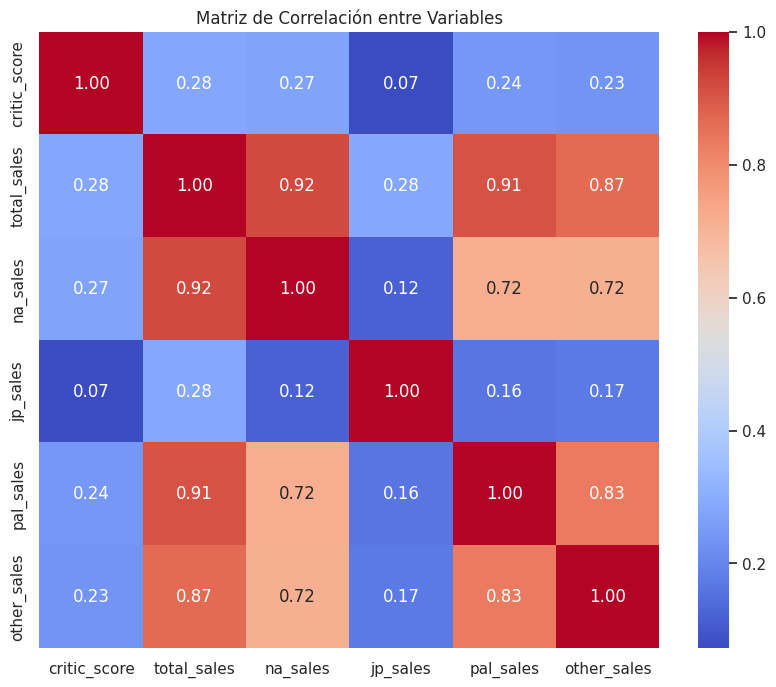

Tendencia: Se observa una correlación muy fuerte entre total_sales y na_sales/pal_sales.


In [14]:
# Análisis de Correlación
# Seleccionamos solo columnas numéricas para la matriz
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación entre Variables')
plt.show()

print("Tendencia: Se observa una correlación muy fuerte entre total_sales y na_sales/pal_sales.")

Coeficiente (Pendiente): 0.1365
R2 Score: 0.0344


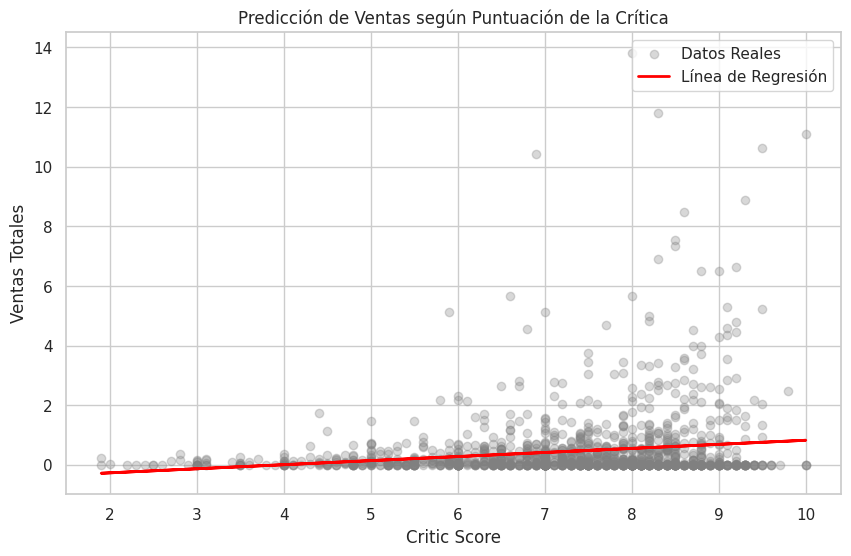

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Preparación de datos para Predicción (Ventas basadas en Critic Score)
# Filtramos datos donde tengamos puntuación mayor a 0
data_reg = df[df['critic_score'] > 0].copy()

X = data_reg[['critic_score']]
y = data_reg['total_sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"Coeficiente (Pendiente): {model.coef_[0]:.4f}")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")

# Visualización de la Regresión
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='gray', alpha=0.3, label='Datos Reales')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Línea de Regresión')
plt.title('Predicción de Ventas según Puntuación de la Crítica')
plt.xlabel('Critic Score')
plt.ylabel('Ventas Totales')
plt.legend()
plt.show()

### Análisis
Aquí calculamos una por una.

In [16]:
# Promedio de ventas de forma manual
suma_de_ventas = df['total_sales'].sum()
cuantos_juegos_hay = len(df)
promedio = suma_de_ventas / cuantos_juegos_hay

print("El total de ventas sumadas es:", suma_de_ventas)
print("La cantidad de juegos es:", cuantos_juegos_hay)
print("Entonces, el promedio es:", promedio)

# El juego que más vendió
venta_maxima = df['total_sales'].max()
print("La venta más alta de un solo juego es:", venta_maxima)

El total de ventas sumadas es: 6605.910000000001
La cantidad de juegos es: 64016
Entonces, el promedio es: 0.10319154586353413
La venta más alta de un solo juego es: 20.32


Ahora hacemos el modelo de predicción.

In [19]:
# Vamos a usar la librería sklearn para predecir
from sklearn.linear_model import LinearRegression
import pandas as pd

# 1. Elegimos nuestras variables
# Para que no de error, usamos juegos con nota Y con ventas mayores a 0
datos_listos = df[(df['critic_score'] > 0) & (df['total_sales'] > 0)]

# Preparamos los datos
columna_nota = datos_listos[['critic_score']]
columna_ventas = datos_listos['total_sales']

# 2. Creamos el modelo (la 'maquina' que aprende)
mi_modelo = LinearRegression()

# 3. Entrenamos el modelo con los datos
mi_modelo.fit(columna_nota, columna_ventas)

# 4. ¿Cuanto vendería un juego si tiene un 9.5 de nota?
# Usamos un DataFrame para que no salga el aviso (Warning)
nota_ejemplo = pd.DataFrame({'critic_score': [9.5]})
prediccion = mi_modelo.predict(nota_ejemplo)

# Mostramos el resultado
print("Si un juego tiene 9.5 de nota, el modelo predice que venderá:", round(prediccion[0], 2), "millones")

Si un juego tiene 9.5 de nota, el modelo predice que venderá: 1.45 millones


### Conclusiones

La gran mayoría del dinero que ganan los videojuegos viene de Norteamérica y Europa. Si un juego tiene éxito allí, es casi seguro que será un éxito mundial.

Por lo general, si el juego tiene mejor nota, vende más, pero hemos visto casos de juegos con notas mediocres que venden bien y juegos excelentes que no venden tanto.

Aunque se fabrican muchísimos juegos de géneros variados (como los de categoría 'Varios'), los que realmente mueven millones de dólares suelen ser de géneros muy específicos que tienen mucha publicidad detras.

Hay una diferencia enorme entre los juegos 'famosos' (los que todos conocemos) y el juego promedio. La mayoría de los juegos venden poquito, mientras que unos pocos se llevan casi todas las ventas.